# Data Science Lab: Lab 1

Submit:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**

**Goals of this Lab:**
1.  Practice with Pandas, Numpy and Data Exploration.
2.  Download a more realistic data set and explore it!
3.  Training vs testing error
4.  (Optional) Review important results from probability, such as the CLT.


In [1]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

#Pandas for data structure and analysis tools
import pandas as pd

#seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

#for nice vector graphics
%matplotlib inline

#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('png', 'pdf')

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)

# Problem 1

In class we explored the diabetes dataset using decision trees.

Part 1. load that data set again.

Part 2. Filter out any data points that missing data -- we did this just for data points that had missing BMI or Glucose values. How many data points did you end up filtering out?

Part 3: Figure out how to run logistic regression from ``sklearn``. Note that except for importing the right sklearn library, your code should adhere to our basic paradigm:
```
model = FamilyOfModels
model.fit(X,y)
model.predict(x)
```

Part 4: Report the accuracy of your model, by using the command ``model.predict`` just like we did for trees.

Part 5: Plot the decision boundary -- this should be a simple cut-and-paste from the code we used.

Bonus: do the same thing for XGBoost.

In [2]:
# Part 1 Load the data
diabetes_data = pd.read_csv("diabetes.csv")
print (diabetes_data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# Part 2: Filter missing data and count number of filtered rows removed
initial_rows = diabetes_data.shape[0]
cols = diabetes_data.columns
for col in cols:
        if not col in ['Pregnancies', 'Outcome']:
                diabetes_data = diabetes_data[(diabetes_data[col] != 0) & (diabetes_data[col].notna())]
final_rows = diabetes_data.shape[0]
rows_removed = initial_rows - final_rows
print(f"Number of rows removed due to missing data: {rows_removed}")

Number of rows removed due to missing data: 376


In [4]:
# Part 3 Logistic Regression Model for diabtests data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100)
X = diabetes_data[['Glucose', 'BMI']].values
y = diabetes_data['Outcome']
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
# Part 4: Evaluate the model
from sklearn.metrics import accuracy_score
y_pred = model.predict(X)
accuracy_score(y, y_pred)

0.7729591836734694

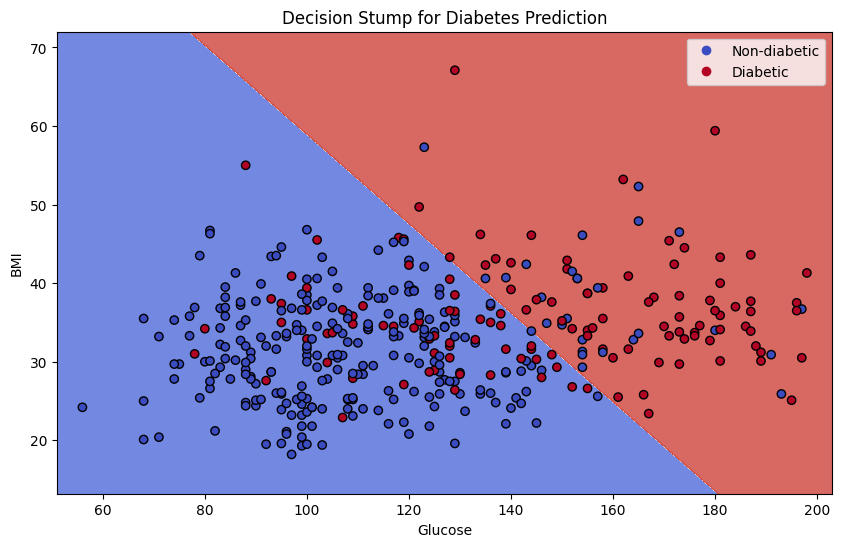

In [7]:
# Part 5 Plot the decison boundary for the features
#Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Decision Stump for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()

In [7]:
# Bonus for XGboost model

# Problem 2

Hospitals are penalized for avoidable 30-day readmissions. We're going to do some preliminary exploration of a data set that explores this topic.

The UCI Diabetes data set assembles a data set with over 100,000 data points, collecting data from 130-US hospitals, compiled over 10 years (1999–2008).

You can load this with the following commands (you may need to ``!pip install ucimlrepo``)
```
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=296)
X_uci = ds.data.features   # pandas DataFrame of features
y_uci  = ds.data.targets    # target(s), incl. readmitted
```

Part 1. How many data points and how many features does the above dataset have? How many of the features are ``numerical``, and how many are ``categorical``?

Part 2. Run the following pandas commands
```
y_uci.value_counts()
X_uci.head()
X_uci.info()
X_uci.describe()
X_uci.isna().sum()
X_uci.isna().mean()
```
and very briefly, say what each command is doing.

Part 3: How many missing values are there per column?  How many rows are complete, i.e., how many rows would survive if we removed each row that had at least one missing value?

Part 4: Plot histograms for each of the following columns:
* "time_in_hospital"
* "num_lab_procedures"
* "num_procedures"
* "num_medications"
* "number_outpatient"
* "number_emergency"
* "number_inpatient"
* "number_diagnoses"

There are many ways to plot a histogram. One way is using ``seaborn`` via the command
``sns.histplot(X_uci['age'].dropna(), bins=30, kde=False)``.

Part 5. (Optional) We're not going to do much more with this dataset, but it's a far richer and more complex dataset than our first Diabetes dataset. Feel free to try running decision trees, logistic regression, or anything else. If you do, I recommend you compare concepts such as **accuracy**, **balanced accuracy**, and **auc_roc** (we will be discussing these a little later).


In [8]:
# Load UCI data
from ucimlrepo import fetch_ucirepo
ds = fetch_ucirepo(id=296)
X_uci = ds.data.features
y_uci = ds.data.targets

/home/sammli/460J_labs/venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [9]:
# Part 1 Dataset analysis
total_features = X_uci.shape[1]
total_data_points = X_uci.shape[0]
print(f"Total features: {total_features}")
print(f"Total data points: {total_data_points}")
# Categorical features
categorical_features = X_uci.select_dtypes(include=['object', 'category']).columns.tolist()
print (f"Total Categorical features: {len(categorical_features)}")
# Numerical features
numerical_features = X_uci.select_dtypes(include=[np.number]).columns.tolist()
print (f"Total Numerical features: {len(numerical_features)}")

Total features: 47
Total data points: 101766
Total Categorical features: 36
Total Numerical features: 11


/tmp/ipykernel_1579/1386386386.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_uci.select_dtypes(include=['object', 'category']).columns.tolist()


In [10]:
# Part running pandas commands
print("Value Counts y_uci\n", y_uci.value_counts(), "\n")
print("Value counts returns a series of unique values and the number ocurrences they had in the pandas dataframe. \n")
print("Head X_uci\n", X_uci.head(), "\n")
print("Head shows the first 5 rows of the dataframe by default, but can return a different number of rows if specified. \n")
print("Info X_uci\n", X_uci.info(), "\n")
print("Info shows a summary of the dataframe including non null counts and data types for each column. \n")
print ("Describe X_uci\n", X_uci.describe(), "\n")
print("Describe shows statistical details for each numerical coulmn in the dataframe with metrics like mean, std, and percentile scores. \n")
print("sum isna X_uci\n", X_uci.isna().sum(), "\n")
print("isna.sum() returns the count of Nan/missing values for each column of the dataframe. \n")
print("mean isna X_uci\n", X_uci.isna().mean(), "\n")
print("isna.mean() returns the fraction of rows that are Nan/missing for each column of the dataframe. \n")

Value Counts y_uci
 readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64 

Value counts returns a series of unique values and the number ocurrences they had in the pandas dataframe. 

Head X_uci
               race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                  

In [11]:
# Part3: Missing row handling
print("Missing Values per column:\n", X_uci.isna().sum(), "\n")
print("Number of complete rows:", X_uci.dropna().shape[0], "\n")

Missing Values per column:
 race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide           

<Axes: xlabel='time_in_hospital', ylabel='Count'>

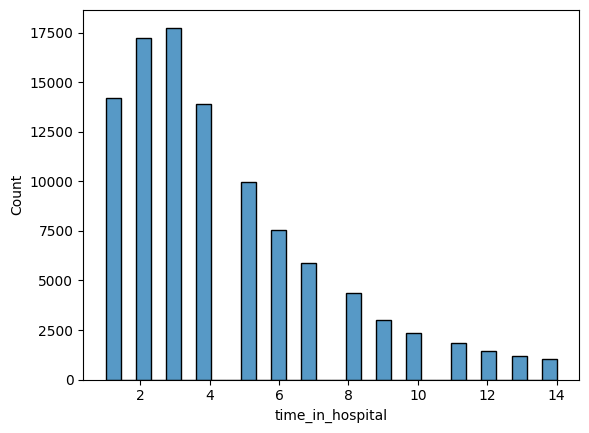

In [12]:
# Part 4 Plotting histograms
sns.histplot(data=X_uci["time_in_hospital"].dropna(), bins=30, kde=False)

<Axes: xlabel='num_lab_procedures', ylabel='Count'>

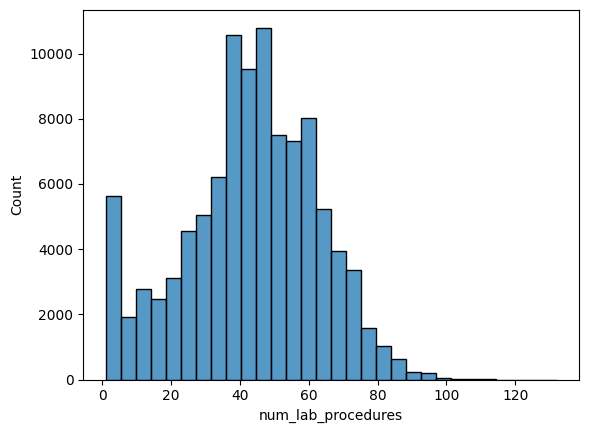

In [13]:
sns.histplot(data=X_uci["num_lab_procedures"].dropna(), bins=30, kde=False)

<Axes: xlabel='num_procedures', ylabel='Count'>

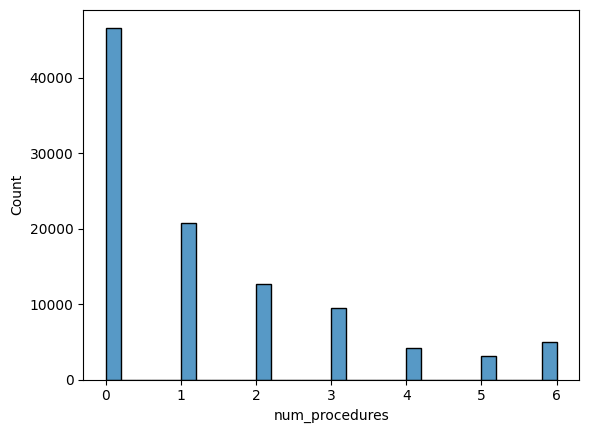

In [14]:
sns.histplot(data=X_uci["num_procedures"].dropna(), bins=30, kde=False)

<Axes: xlabel='num_medications', ylabel='Count'>

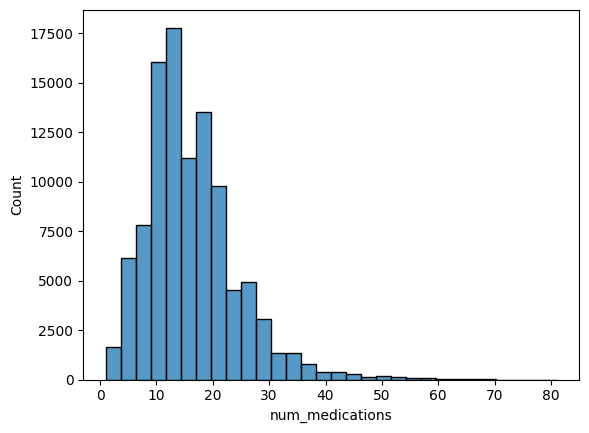

In [15]:
sns.histplot(data=X_uci["num_medications"].dropna(), bins=30, kde=False)

<Axes: xlabel='number_outpatient', ylabel='Count'>

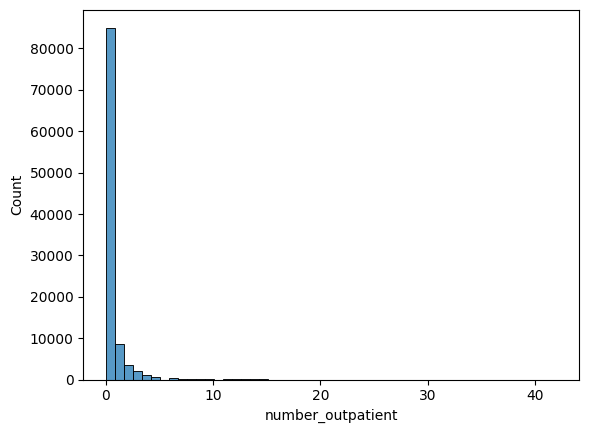

In [16]:
sns.histplot(data=X_uci["number_outpatient"].dropna(), bins=50, kde=False)

<Axes: xlabel='number_emergency', ylabel='Count'>

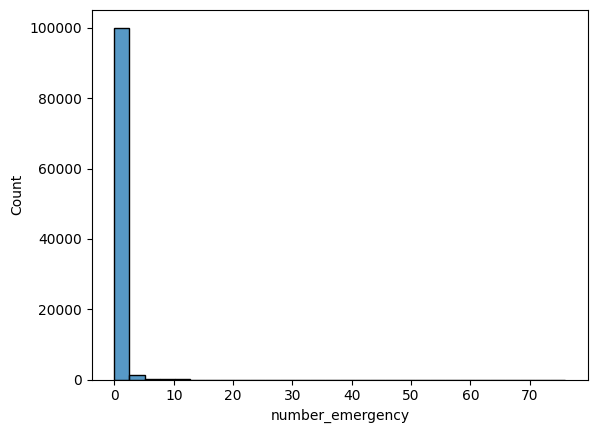

In [17]:
sns.histplot(data=X_uci["number_emergency"].dropna(), bins=30, kde=False)

<Axes: xlabel='number_inpatient', ylabel='Count'>

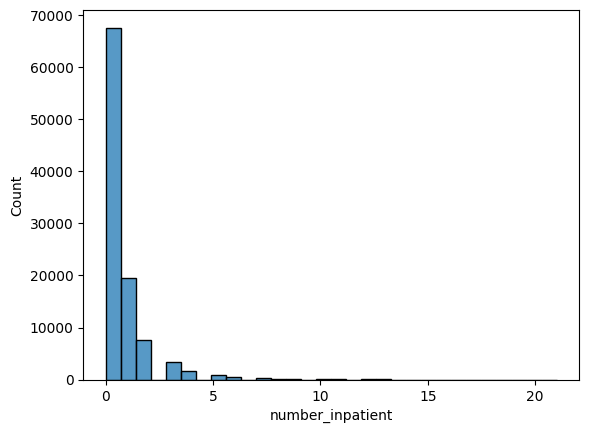

In [18]:
sns.histplot(data=X_uci["number_inpatient"].dropna(), bins=30, kde=False)

<Axes: xlabel='number_diagnoses', ylabel='Count'>

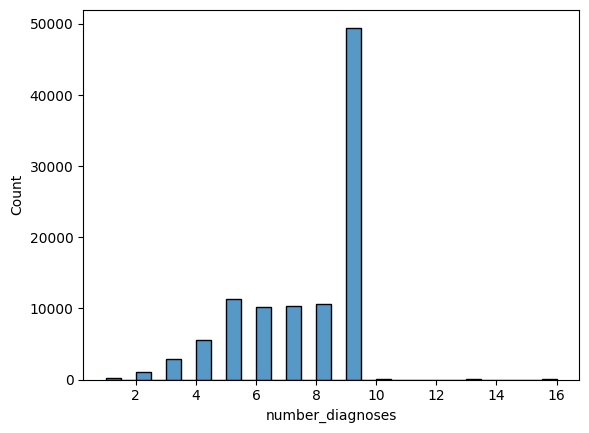

In [19]:
sns.histplot(data=X_uci["number_diagnoses"].dropna(), bins=30, kde=False)

# Problem 3

The goal of this exercise is for you to get more experience with Pandas, and to get a chance to explore a cool data set.  Download the file Names.zip from Canvas.  This contains the frequency of all names that appeared more than 5 times on a social security application from 1880 through 2015.

Part 1. Write a program that on input $k$ and XXXX, returns the top $k$ names from year XXXX.

Part 2. Write a program that on input Name returns the frequency for men and women of the name Name.

Part 3. It could be that names are more diverse now than they were in 1880, so that a name may be relatively the most popular, though its frequency may have been decreasing over the years.  Modify the above to return the relative frequency.

Part 4. Find all the names that used to be more popular for one gender, but then became more popular for another gender.

•(Optional) Find something cool about this data set.

In [8]:
# Part 1: top k names from year XXXX
def get_topk_names(year:int, k:int):
    yob_data = pd.read_csv(f"Names/yob{year}.txt", header=None, names=["Name", "Sex", "Count"])
    counts = yob_data.groupby('Name')['Count'].sum()
    topk_names = counts.sort_values(ascending=False).head(k).index.tolist()
    return topk_names

get_topk_names(2000, 5)

['Jacob', 'Michael', 'Matthew', 'Joshua', 'Emily']

In [9]:
# Part 2: get frequency of name across years
def get_name_frequencies(name:str)->int:
    count = 0
    for year in range(1880, 2016):
        yob_data = pd.read_csv(f"Names/yob{year}.txt", header=None, names=["Name", "Sex", "Count"])
        name_count = yob_data[yob_data['Name'] == name]['Count'].sum()
        count += name_count
    return count

get_name_frequencies("Samuel")

np.int64(731596)

In [22]:
# Part 3: Relative frequencies of names across years
def get_relative_frequencies(name:str)->float:
    total_count = 0
    name_count = 0
    for year in range(1880, 2016):
        yob_data = pd.read_csv(f"Names/yob{year}.txt", header=None, names=["Name", "Sex", "Count"])
        year_total = yob_data['Count'].sum()
        name_year_count = yob_data[yob_data['Name'] == name]['Count'].sum()
        total_count += year_total
        name_count += name_year_count
    if total_count == 0:
        return 0.0
    return name_count / total_count

get_relative_frequencies("William")

np.float64(0.011992175651929452)

In [23]:
def get_name_flips(start_year=1880, end_year=2015):
    df_start = pd.read_csv(f"Names/yob{start_year}.txt", header=None, names=["Name", "Sex", "Count"])
    df_end = pd.read_csv(f"Names/yob{end_year}.txt", header=None, names=["Name", "Sex", "Count"])

    pivot_start = df_start.pivot(index="Name", columns="Sex", values="Count").fillna(0)
    pivot_end = df_end.pivot(index="Name", columns="Sex", values="Count").fillna(0)

    pivot_start["Mostly_Male"] = pivot_start["M"] > pivot_start["F"]
    pivot_end["Mostly_Male"] = pivot_end["M"] > pivot_end["F"]

    combined = pivot_start.join(pivot_end, lsuffix='_start', rsuffix='_end').dropna()

    flips = []
    for n, row in combined.iterrows():
        if row['Mostly_Male_start'] != row['Mostly_Male_end']:
            flips.append(n)
    return flips

get_name_flips(1880, 2015)

['Addison',
 'Allison',
 'Alpha',
 'Alva',
 'Arlie',
 'Artie',
 'Ashby',
 'Ashley',
 'Aubrey',
 'Avery',
 'Bailey',
 'Beverly',
 'Billie',
 'Charley',
 'Clair',
 'Clarke',
 'Dana',
 'Davie',
 'Donnie',
 'Edie',
 'Elza',
 'Elzie',
 'Emerson',
 'Emery',
 'Emory',
 'Fate',
 'Fay',
 'Finley',
 'Harley',
 'Hollie',
 'Holly',
 'Isa',
 'Ivey',
 'Ivory',
 'Jean',
 'Joan',
 'Jodie',
 'Justice',
 'Kelly',
 'Lacy',
 'Larkin',
 'Leone',
 'Leslie',
 'Lindsay',
 'Lindsey',
 'Llewellyn',
 'Loran',
 'Loren',
 'Lorin',
 'Lou',
 'Lynn',
 'Madison',
 'Marion',
 'Merida',
 'Merrill',
 'Merritt',
 'Monroe',
 'Morgan',
 'Nova',
 'Ollie',
 'Orla',
 'Palmer',
 'Payton',
 'Pink',
 'Presley',
 'Raleigh',
 'Reese',
 'Riley',
 'Robbie',
 'Sandy',
 'Shelby',
 'Shirley',
 'Sidney',
 'Sol',
 'Stacy',
 'Starling',
 'Sydney',
 'Taylor',
 'Tennessee',
 'Texas',
 'Tracy',
 'Valentine',
 'Vinnie',
 'Worthy']

# Problem 4

We looked at the MNIST data set in class (see the notebook in ``pages`` in Canvas). Recall that MNIST is a data set of handwritten digits. It is considered one of the ``easiest'' image recognition problems in computer vision, and we will see it again.

This exercise is simple exercise, and an opportunity to play around with this data set.

**Parts 1 to 7: Nothing to submit!** just run through the notebook we saw in class and try to make sure you understand all the commands.

Part 1. Make sure you can run through the entire Colab notebook posted. Especially if you haven't used Python, try to understand what every line is doing.

Part 2. How many data points are there, how many features are there, and what do the features represent?

Part 3. Compute how many times each digit appears in the dataset.

Part 4. Read the documentation for sklearn.model_selection.train_test_split and explain what this does.

Part 5. Read the documentation for DecisionTreeClassifier, and explain what score means.

Part 6. What happens to the **training score** as you increase the depth of the tree? Explain.

Part 7. What happens to the difference between **training score** and **testing score** as you increase the depth of the tree? Explain.

my responses: train test split, parititon the dataset for training and testing datset reandomly. scorereturns the average/mean accuracy. Training score will increase until model learns the entire training set. testing score will plateau and stop decreasing

**Only submit your answer to this part**

Part 8. Fix the depth of the tree. For this example, use depth=6 (nothing special about the number 6, just to illustrate the concept). Then plot the difference of training score - testing score when you train on: 100, 500, 5000, 10000, 20,0000, 60,000 training points, always computing testing score by evaluating on the 10,000 testing points. Plot this trend.  Try to explain what you are seeing.  


In [24]:
import numpy as np
from torchvision import datasets, transforms

# Custom transform to convert tensor to numpy array and remove channel dimension
class ToNumpyNoChannel:
    def __call__(self, tensor):
        return tensor.squeeze(0).numpy()  # Remove channel dimension (C, H, W -> H, W)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to PyTorch tensor
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize to [-1, 1]
    ToNumpyNoChannel()  # Convert tensor to numpy array and remove channel dimension
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Access data and labels as NumPy arrays
X_train = np.array([train_dataset[i][0] for i in range(len(train_dataset))])  # Features
y_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])  # Labels
X_test = np.array([test_dataset[i][0] for i in range(len(test_dataset))])    # Features
y_test = np.array([test_dataset[i][1] for i in range(len(test_dataset))])    # Labels

In [25]:
"""
Now we do a random permutation of the data. This is often a good idea,
especially when we don't know how the data were created. For example, maybe
the digits were all given in order.
"""
import time
from sklearn.utils import check_random_state

t0 = time.time()
random_state = check_random_state(0)
permutation = random_state.permutation(X_train.shape[0])
X_train = X_train[permutation]
y_train = y_train[permutation]
permutation = random_state.permutation(X_test.shape[0])
X_test = X_test[permutation]
y_test = y_test[permutation]

In [26]:
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

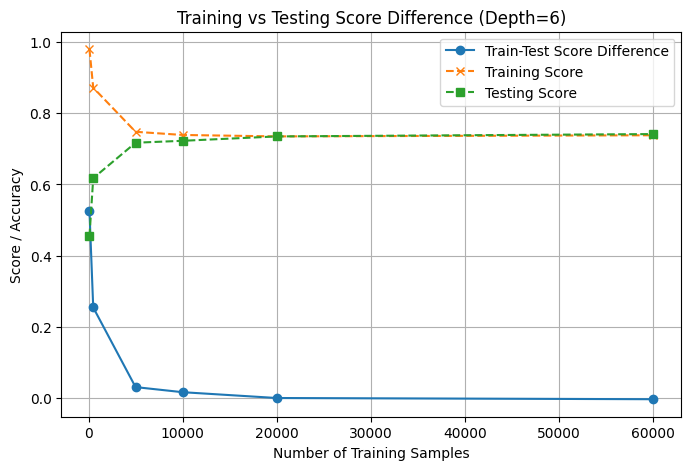

As we increase the training set size, the difference between training and testing scores decreases, indicating reduced overfitting as the training and testing accfruacy converge


In [27]:
# Part 8: Plot training score - testing score for different training set sizes (depth=6)
import matplotlib.pyplot as plt
from sklearn import tree

train_sizes = [100, 500, 5000, 10000, 20000, 60000]
diff_scores = []
training_scores = []
testing_scores = []

for train_samples in train_sizes:
    # Select subset for training
    X_train_subset = X_train[:train_samples]
    y_train_subset = y_train[:train_samples]
    dt = tree.DecisionTreeClassifier(max_depth=6, criterion='gini')
    dt.fit(X_train_subset, y_train_subset)
    train_score = dt.score(X_train_subset, y_train_subset)
    test_score = dt.score(X_test, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)
    diff_scores.append(train_score - test_score)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, diff_scores, marker='o', label='Train-Test Score Difference')
plt.plot(train_sizes, training_scores, marker='x', linestyle='--', label='Training Score')
plt.plot(train_sizes, testing_scores, marker='s', linestyle='--', label='Testing Score')
plt.xlabel('Number of Training Samples')
plt.ylabel('Score / Accuracy')
plt.title('Training vs Testing Score Difference (Depth=6)')
plt.legend()
plt.grid(True)
plt.show()

print("As we increase the training set size, the difference between training and testing scores decreases, indicating reduced overfitting as the training and testing accfruacy converge")

# Problem 5

We now turn to a somewhat more sophisticated data set: CIFAR10.

Load the data using:
```
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
```

Part 1. How many data points are there, and how many labels? How many points for each label?

Part 2. Figure out how to display some of the images from CIFAR10.

Part 3: Reshape X_train into a matrix X_tr so that each row is a data point.
 What are the dimensions of X_train?

Part 4: Generate decision trees of depth 1 to 15, and for each, compute the training accuracy and the testing accuracy.

If you did this correctly and ran the notebook, you noticed that CIFAR10 indeed looks like a ``harder'' problem. Deep trees are again doing very well on the training set, and they do a little better than guessing on the testing data, but not as well as they do on MNIST. We will revisit CIFAR10 several times, as we develop more powerful tools. And we will see that we will do much better than deep decision trees!

In [28]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
label_categories = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

2026-01-26 18:38:43.618154: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-26 18:38:43.955106: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-26 18:38:45.136834: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sammli/460J_labs/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: Vi

In [29]:
# Part 1 number of datapoints and labels
X_train_flat = X_train.reshape((X_train.shape[0], -1)) if X_train.ndim > 2 else X_train

num_datapoints = X_train_flat.shape[0]
num_labels = len(np.unique(y_train))
num_features = X_train_flat.shape[1]

# Counts per label
labels, counts = np.unique(y_train.flatten(), return_counts=True)
counts_per_label = dict(zip(labels.tolist(), counts.tolist()))

print(f"Number of datapoints: {num_datapoints}")
print(f"Number of labels: {num_labels}")
print(f"Number of features per datapoint: {num_features}")
print(f"Counts per label: {counts_per_label}")

Number of datapoints: 50000
Number of labels: 10
Number of features per datapoint: 3072
Counts per label: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}


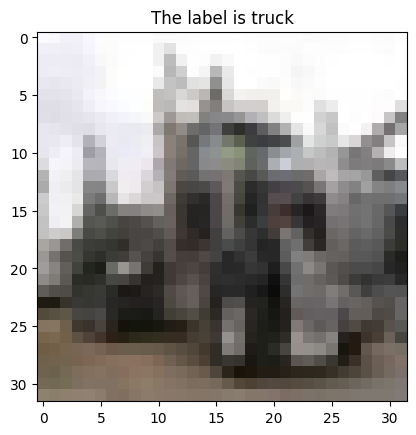

In [30]:
# Part 2 display sample images
index = 1233
img = X_train[index]
label = y_train[index]
#img = img.reshape((28, 28))

# Plot it along with its label
plt.title('The label is {label}'.format(label=label_categories[label.item()]))
plt.imshow(img)
plt.show()

In [31]:
# PArt 3 reshaping X_train into a matrix
X_tr = X_train.reshape((X_train.shape[0], -1))
X_te = X_test.reshape((X_test.shape[0], -1))
print('X_tr.shape =', X_tr.shape)

X_tr.shape = (50000, 3072)


In [32]:
# Gernate decison trees
training_scores = []
testing_scores = []
depth_values = range(15)
for depth in depth_values:
    dt = tree.DecisionTreeClassifier(max_depth=depth+1, criterion='gini')
    dt.fit(X_tr,y_train)
    train_score = dt.score(X_tr,y_train)
    test_score = dt.score(X_te, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)

print('These are the training scores:',training_scores)
print('These are the testing scores:',testing_scores)


These are the training scores: [0.15696, 0.19266, 0.23762, 0.25714, 0.26764, 0.29588, 0.32234, 0.34962, 0.38274, 0.42642, 0.47904, 0.5371, 0.601, 0.6645, 0.72732]
These are the testing scores: [0.157, 0.1955, 0.2394, 0.2527, 0.2669, 0.2812, 0.2929, 0.3023, 0.304, 0.306, 0.3019, 0.3027, 0.2942, 0.2912, 0.2877]


# The next two problems are optional, but recommended

We will be generating lots of random data sets in this class, in order to test the behavior of machine learning algorithms.

So it's useful to know how to generate random data, and display it.

# Problem 6 (Optional, recommended)

**Part 1.** Generate 1,000 samples of 2 dimensional data from the Gaussian distribution $\left(\begin{array}{cc}X_{i}\\Y_{i}\end{array}\right)∼N\biggl(\left(\begin{array}{cc}-5\\5\end{array}\right),\left(\begin{array}{cc}2 & 0.8\\0.8 & 3\end{array}\right)\biggr)$.

**Part 2.** Plot these points.

**Part 3.** Find the Eigenvectors and Eigenvalues of the covariance matrix using np.linalg.eig, or np.linalg.eigh, or something else of your choice.

**Part 4.** Now take the 1,000 points you generated in the first part, and use them to estimate the mean and covariance matrix for this multi-dimensional data using elementary numpy commands, i.e., addition, multiplication, division (do not use a command that takes data and returns the mean or standard deviation).

*Remark*: If you did this correctly: You should have made a number of observations. (i) The points you plotted should look like an elongated ellipse. (ii) The axis of elongation (the major axis of the ellipse) should be aligned with the eigenvector you computed that has the largest eigenvalue. The minor axis, should be aligned with the other eigenvector you computed. (iii) In the last part, you computed what is called the *empirical covariance* matrix. This should be quite close to the covariance matrix you used to generate the data. If we used more and more points (10,000, 100,000, etc.), then our empirical estimate would look more and more like what we used to generate the data.


# Problem 7: Central Limit Theorem (Optional, recommended)

Back in EE351K you learned the Law of Large Numbers, and the Central Limit Theorem, among many other things. The Law of Large Numbers says that if $X_i$ are independent and identically distributed (iid) random variables, then $(1/N) \sum X_i$ converges to $\mathbb{E}[X]$. That's the law of large numbers.

You also learned the Central Limit Theorem. This says that if $X_i$ are zero mean, have variance 1, and are iid, then $(1/\sqrt{N}) \sum X_i$ converges to a random variable. Which random variable? A standard (zero mean, unit variance) Gaussian.

We're going to check the central limit theorem empirically, as an excuse to do more practice with Python and numpy and basic plotting.

Let $X_i$ be an iid Bernoulli random variable with value \{-1,1\}. Look at the random variable
$Z_n = \frac{1}{\sqrt{n}}\sum X_i$. By taking 1000 samples from $Z_n$, plot its histogram. **Note**: To generate 1,000 samples from $Z_n$, you need to generate $1,000 \times n$ samples of $X_i$, since each $Z$ needs $1,000$ $X_i$'s. Now check that for small $n$ (set $n= 5$) $Z_n$ does not look that much like a Gaussian, but when $n$ is bigger (set $n = 50$) it looks much more like a Gaussian. Check also for much bigger $n$: $n = 250$, to see that at this point, one can really see the bell curve.